<a href="https://colab.research.google.com/github/Ankit-ally/Ankit-ally/blob/main/EcoType_Forest_Cover_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project by mr. ankit jitendra sharma
Title:- EcoType ForestCover Prediction

Technical Tags:
machine learning, classification, random forest, decision tree, logistic regression, xgboost, knn, model evaluation, feature engineering, feature importance, outlier detection, skewness treatment, data imbalance handling, random oversampling, streamlit, model deployment, forest cover type prediction, scikit-learn, imbalanced-learn, exploratory data analysis, eda, matplotlib, seaborn, pkl model saving, numeric input handling, web app development


In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Data gathering from local source of google collab and attach a path .csv

In [ ]:
df = pd.read_csv('/content/cover_type (1).csv')

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


###== CHECKING BASIC DETAILS ###

In [ ]:
# Shape of dataset
df.shape

(145890, 13)

In [ ]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
# Statistical summary
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [ ]:
# Target column distribution  #####>>>>>>. checking the targated variables
df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


Data Understanding (EDA - Deep Analysis)
[

Understand data types,
Check missing values,,,,
Detect duplicates,
Analyze target distribution,
Get initial insights.]

In [ ]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:\n", df.columns.tolist())

Shape of dataset: (145890, 13)

Columns:
 ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area', 'Soil_Type']


In [ ]:
df.info()         ######### dat atypes and information of data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
df.describe().T  # stastical summary

,count,mean,std,min,25%,50%,75%,max
Elevation,145890.0,2874.458949,210.801279,1863.0,2747.0,2909.0,3004.0,3849.0
Aspect,145890.0,141.127418,107.719296,0.0,54.0,108.0,217.0,360.0
Slope,145890.0,11.925574,6.319326,0.0,7.0,11.0,15.0,61.0
Horizontal_Distance_To_Hydrology,145890.0,251.824738,192.473899,0.0,95.0,212.0,362.0,1343.0
Vertical_Distance_To_Hydrology,145890.0,34.554322,41.215776,-146.0,7.0,23.0,51.0,554.0
Horizontal_Distance_To_Roadways,145890.0,3313.827541,1687.779953,0.0,1848.0,3420.0,4673.0,7117.0
Hillshade_9am,145890.0,217.368106,21.590298,0.0,207.0,222.0,232.0,254.0
Hillshade_Noon,145890.0,224.874748,16.084851,99.0,216.0,226.0,236.0,254.0
Hillshade_3pm,145890.0,139.788203,31.311690,0.0,121.0,140.0,159.0,248.0
Horizontal_Distance_To_Fire_Points,145890.0,3044.958105,1761.882341,0.0,1608.0,2713.0,4478.0,7173.0


In [ ]:
# Missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
df['Cover_Type'].value_counts()    # target var analysis4


,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [ ]:
# Percentage distribution
df['Cover_Type'].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


📊 Visualize Target Distribution

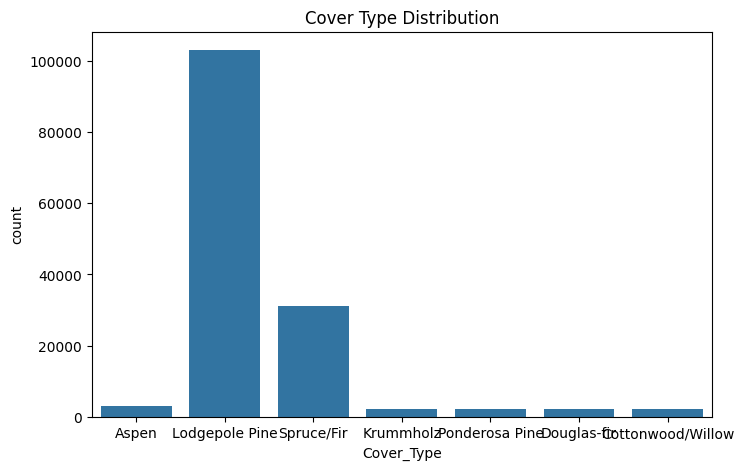

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type', data=df)
plt.title("Cover Type Distribution")
plt.show()

# checking in corelation heat map

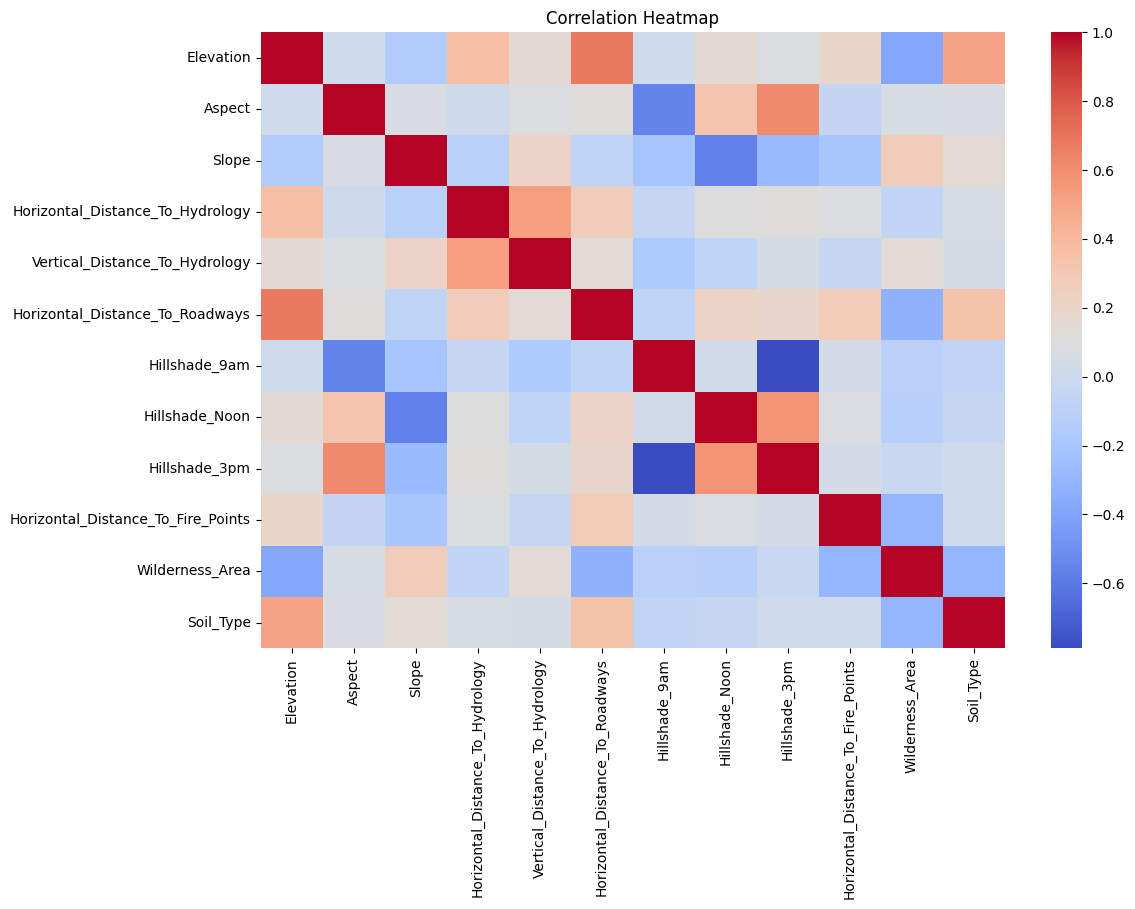

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

🧹  Data Cleaning & Transformation

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
print("No missing values found ✅")

No missing values found ✅


In [ ]:
# Fill numerical columns with median
# df.fillna(df.median(), inplace=True) # This line caused an error because 'Cover_Type' is non-numeric, and it's also not needed as there are no missing values.

Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)
# Verify
print("New shape:", df.shape)

New shape: (145890, 13)


 Outlier Detection (IQR Method)
 detect outliers in numerical columns.

In [ ]:
# Select numeric columns (excluding target)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area',
 'Soil_Type']

📊 Visualize Outliers (Boxplot)

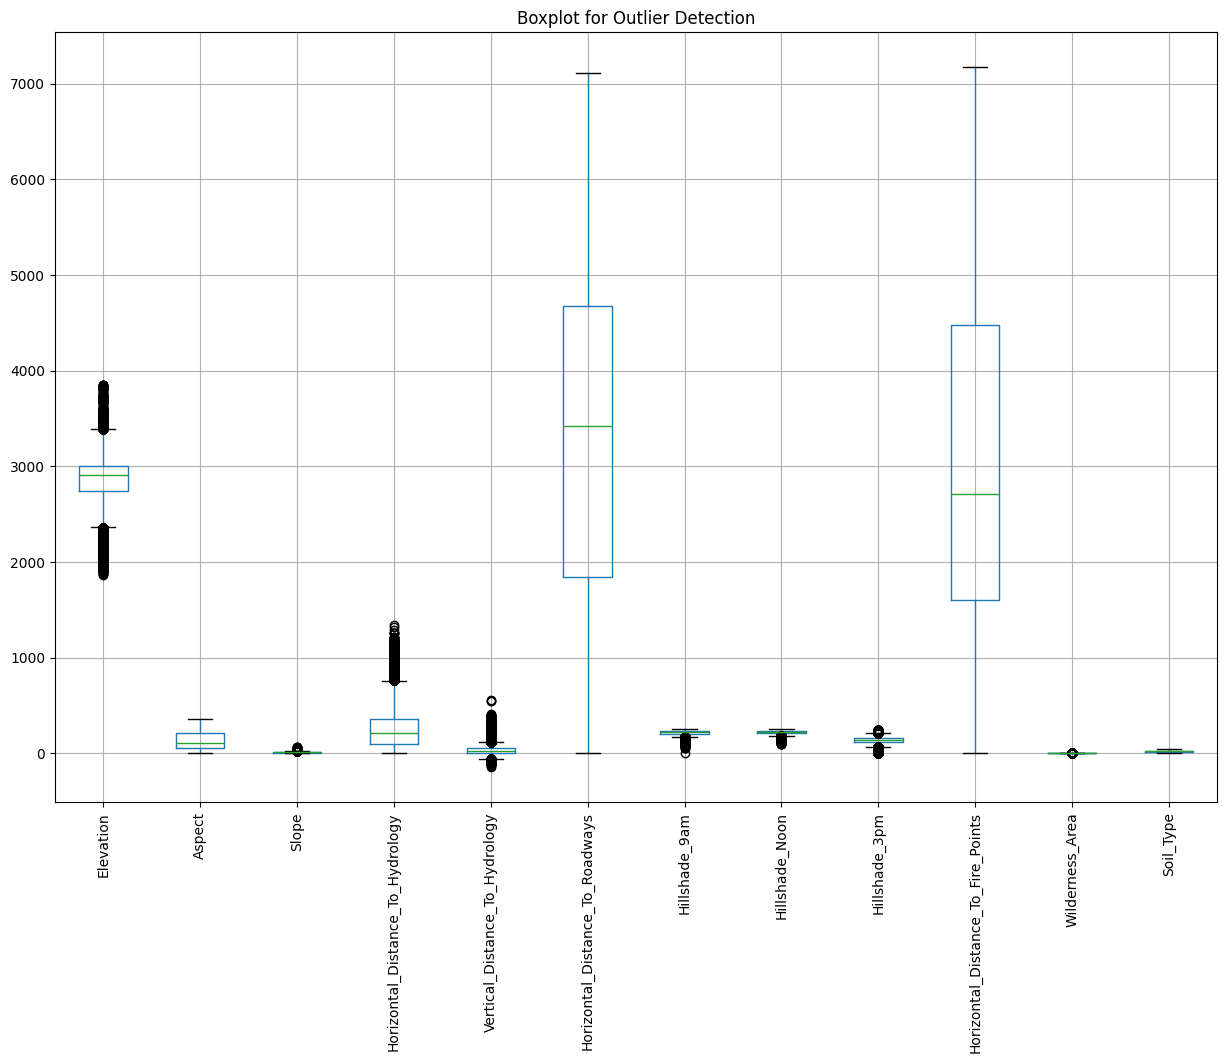

In [ ]:
plt.figure(figsize=(15,10))
df[num_cols].boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

🔧 Remove Outliers using IQR

In [ ]:
def remove_outliers_iqr(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

    return data

df = remove_outliers_iqr(df, num_cols)

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (119955, 13)


Skewness Check

In [ ]:
# Check skewness
skewness = df[num_cols].skew()
skewness.sort_values(ascending=False)

,0
Aspect,0.823726
Vertical_Distance_To_Hydrology,0.757943
Horizontal_Distance_To_Hydrology,0.678711
Slope,0.316817
Horizontal_Distance_To_Fire_Points,0.295874
Hillshade_3pm,0.091391
Wilderness_Area,0.000000
Horizontal_Distance_To_Roadways,-0.095538
Elevation,-0.144639
Hillshade_Noon,-0.237175


fix it

In [ ]:
skewed_cols = skewness[abs(skewness) > 1].index

# Apply log1p transformation
for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [ ]:
## fial chek

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,119955.0,2886.211963,168.439963,2473.0,2760.0,2913.0,2998.0,3389.0
Aspect,119955.0,134.281622,104.256061,0.0,53.0,103.0,191.0,359.0
Slope,119955.0,10.562044,4.816287,0.0,7.0,10.0,14.0,27.0
Horizontal_Distance_To_Hydrology,119955.0,237.460623,170.187551,0.0,95.0,210.0,350.0,750.0
Vertical_Distance_To_Hydrology,119955.0,26.368005,27.760108,-58.0,6.0,20.0,43.0,113.0
Horizontal_Distance_To_Roadways,119955.0,3390.893293,1614.398507,30.0,2079.0,3497.0,4652.0,7117.0
Hillshade_9am,119955.0,220.263641,16.523876,172.0,210.0,223.0,233.0,253.0
Hillshade_Noon,119955.0,226.834463,12.956917,191.0,218.0,227.0,236.0,254.0
Hillshade_3pm,119955.0,139.515285,25.640115,70.0,122.0,139.0,156.0,209.0
Horizontal_Distance_To_Fire_Points,119955.0,3202.115885,1725.326475,0.0,1822.0,2883.0,4607.0,7173.0


Feature Engineering

In [ ]:
# Check unique values
print("Wilderness_Area unique values:", df['Wilderness_Area'].unique())
print("Soil_Type unique values:", df['Soil_Type'].unique())

Wilderness_Area unique values: [1]
Soil_Type unique values: [29 12 18 30 16 20 24 23 40 19  8 22 39  9 38 37 35  7  1]


# Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le_wilderness = LabelEncoder()
le_soil = LabelEncoder()

# Apply encoding
df['Wilderness_Area'] = le_wilderness.fit_transform(df['Wilderness_Area'])
df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])

In [ ]:
import joblib

joblib.dump(le_wilderness, 'wilderness_encoder.pkl')
joblib.dump(le_soil, 'soil_encoder.pkl')

['soil_encoder.pkl']

**Save Encoders (IMPORTANT for Streamlit later)::**

----------------


Feature Creation (Power Boost)

In [ ]:
# Distance ratio feature
# Handle potential division by zero when Vertical_Distance_To_Hydrology is -1
df['Hydrology_Distance_Ratio'] = np.where(
    df['Vertical_Distance_To_Hydrology'] + 1 == 0,
    0,  # Assign 0 if denominator is 0
    df['Horizontal_Distance_To_Hydrology'] / (df['Vertical_Distance_To_Hydrology'] + 1)
)

# Hillshade difference
df['Hillshade_Diff'] = df['Hillshade_Noon'] - df['Hillshade_9am']

# Total distance feature
df['Total_Distance'] = (
    df['Horizontal_Distance_To_Hydrology'] +
    df['Horizontal_Distance_To_Roadways'] +
    df['Horizontal_Distance_To_Fire_Points']
)

Feature and Target Split

In [ ]:
# Features and target
# Drop 'Cover_Type' and 'Wilderness_Area' (due to zero variance after outlier removal)
X = df.drop(['Cover_Type', 'Wilderness_Area'], axis=1)
y = df['Cover_Type']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (119955, 14)
Target shape: (119955,)


Train Test And Splitz

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (95964, 14)
Test shape: (23991, 14)


# very important Model Building

In [ ]:
# MODEL BUILDING
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Train Model

In [ ]:
print("Columns in X_train with infinite values:")
print(X_train.columns[np.isinf(X_train).any()].tolist())

print("\nMaximum values in X_train (across all columns):")
print(X_train.max().sort_values(ascending=False))


Columns in X_train with infinite values:
[]

Maximum values in X_train (across all columns):
Total_Distance                        13114.0
Horizontal_Distance_To_Fire_Points     7173.0
Horizontal_Distance_To_Roadways        7117.0
Elevation                              3388.0
Horizontal_Distance_To_Hydrology        750.0
Hydrology_Distance_Ratio                720.0
Aspect                                  359.0
Hillshade_Noon                          254.0
Hillshade_9am                           253.0
Hillshade_3pm                           209.0
Vertical_Distance_To_Hydrology          113.0
Hillshade_Diff                           79.0
Slope                                    27.0
Soil_Type                                18.0
dtype: float64


In [ ]:
import numpy as np

# Check for infinite values in X_train
if np.isinf(X_train).any().any():
    print("X_train contains infinite values.")
else:
    print("X_train does not contain any infinite values.")


X_train does not contain any infinite values.



Classification Report:
                precision    recall  f1-score   support

         Aspen       0.92      0.72      0.81       260
     Krummholz       0.88      0.90      0.89        78
Lodgepole Pine       0.97      0.99      0.98     18304
    Spruce/Fir       0.96      0.89      0.92      5349

      accuracy                           0.96     23991
     macro avg       0.93      0.87      0.90     23991
  weighted avg       0.96      0.96      0.96     23991


Confusion Matrix:


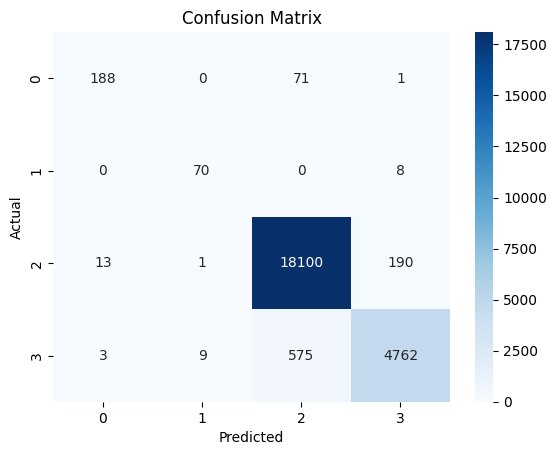

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Identify and replace infinite values in 'Hydrology_Distance_Ratio' for X_train and X_test
# The problematic column was identified as 'Hydrology_Distance_Ratio' which was showing inf values.
# Replacing infinite values with 0. This is a pragmatic solution to allow model training to proceed.
# Ideally, the upstream feature engineering and data splitting cells should be re-run.
X_train.replace([np.inf, -np.inf], 0, inplace=True)
X_test.replace([np.inf, -np.inf], 0, inplace=True)

print("Infinite values in X_train after replacement:")
print(X_train.columns[np.isinf(X_train).any()].tolist())
print("Infinite values in X_test after replacement:")
print(X_test.columns[np.isinf(X_test).any()].tolist())


Infinite values in X_train after replacement:
[]
Infinite values in X_test after replacement:
[]


In [ ]:
# Fit the RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.9650285523738068


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9509399358092618


### Feature Scaling

Logistic Regression is sensitive to the scale of features, so we'll scale `X_train` and `X_test` using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names for easier inspection if needed
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")

Features scaled successfully!


In [ ]:
lr_model = LogisticRegression(max_iter=1000)       #### logistic regression
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8411070818223501


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)       ### knn
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9133008211412613


Install & Train XGBoost

In [ ]:
!pip install xgboost

In [ ]:
# from xgboost import XGBClassifier

# xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
# xgb_model.fit(X_train, y_train)

# xgb_pred = xgb_model.predict(X_test)

# print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Initialize LabelEncoder for the target variable
le_cover_type = LabelEncoder()

# Fit and transform y_train and transform y_test
y_train_encoded = le_cover_type.fit_transform(y_train)
y_test_encoded = le_cover_type.transform(y_test)

# Save the encoder for future use (e.g., deployment)
joblib.dump(le_cover_type, 'cover_type_encoder.pkl')

print("Target variable encoded successfully!")
print("Original classes:", le_cover_type.classes_)
print("Encoded classes in y_train:", np.unique(y_train_encoded))
print("Encoded classes in y_test:", np.unique(y_test_encoded))

Target variable encoded successfully!
Original classes: ['Aspen' 'Krummholz' 'Lodgepole Pine' 'Spruce/Fir']
Encoded classes in y_train: [0 1 2 3]
Encoded classes in y_test: [0 1 2 3]


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded) # Use encoded y_train

xgb_pred_encoded = xgb_model.predict(X_test)

# Decode predictions back to original labels for accuracy calculation and reporting
xgb_pred = le_cover_type.inverse_transform(xgb_pred_encoded)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9539827435288233


### Encoding Target Variable for XGBoost

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Initialize LabelEncoder for the target variable
le_cover_type = LabelEncoder()

# Fit and transform y_train and transform y_test
y_train_encoded = le_cover_type.fit_transform(y_train)
y_test_encoded = le_cover_type.transform(y_test)

# Save the encoder for future use (e.g., deployment)
joblib.dump(le_cover_type, 'cover_type_encoder.pkl')

print("Target variable encoded successfully!")
print("Original classes:", le_cover_type.classes_)
print("Encoded classes in y_train:", np.unique(y_train_encoded))
print("Encoded classes in y_test:", np.unique(y_test_encoded))

Target variable encoded successfully!
Original classes: ['Aspen' 'Krummholz' 'Lodgepole Pine' 'Spruce/Fir']
Encoded classes in y_train: [0 1 2 3]
Encoded classes in y_test: [0 1 2 3]


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded) # Use encoded y_train

xgb_pred_encoded = xgb_model.predict(X_test)

# Decode predictions back to original labels for accuracy calculation and reporting
xgb_pred = le_cover_type.inverse_transform(xgb_pred_encoded)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9539827435288233


Compairing all model from detail prespective

In [ ]:
results = {
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

results

{'Random Forest': 0.9650285523738068,
 'Decision Tree': 0.9509399358092618,
 'Logistic Regression': 0.8411070818223501,
 'KNN': 0.9133008211412613,
 'XGBoost': 0.9539827435288233}

Detailed Evaluation (Best Model)

In [ ]:
print(classification_report(y_test, rf_pred))

                precision    recall  f1-score   support

         Aspen       0.93      0.75      0.83       260
     Krummholz       0.89      0.91      0.90        78
Lodgepole Pine       0.97      0.99      0.98     18304
    Spruce/Fir       0.96      0.89      0.93      5349

      accuracy                           0.97     23991
     macro avg       0.94      0.89      0.91     23991
  weighted avg       0.96      0.97      0.96     23991



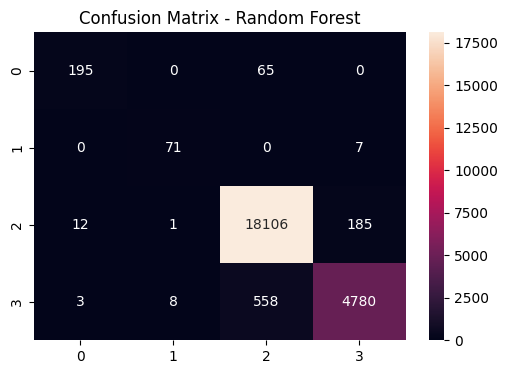

In [ ]:
conf_matrix = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

Results Summary

In [ ]:
# Convert results to DataFrame for better view
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

,Model,Accuracy
0,Random Forest,0.965029
4,XGBoost,0.953983
1,Decision Tree,0.950940
3,KNN,0.913301
2,Logistic Regression,0.841107


📊 Visual Comparison

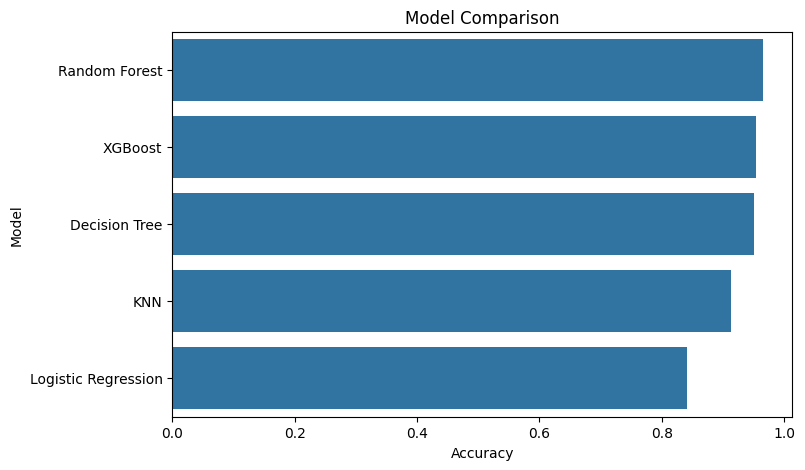

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title("Model Comparison")
plt.show()

best model: Random Forest
Accuracy : 0.963695


In [ ]:
##Hyperparameter Tuning (Random Forest)
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

Apply grid


In [ ]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1]
}

In [ ]:
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=8,
    cv=2,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [ ]:
random_search.fit(X_sample, y_sample)

print("Best Params:", random_search.best_params_)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Tuned Accuracy: 0.9353090742361719


In [ ]:
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 8 candidates, totalling 16 fits


RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, verbose=2)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,      # keep small for speed
    cv=2,          # faster
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# 🔥 IMPORTANT: RUN THIS CELL FULLY
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [50, 100]},
                   random_state=42, verbose=2)

In [ ]:
print("Best Params:", random_search.best_params_)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Tuned Accuracy: 0.9629861197949231


lets do a quick debugg

In [ ]:
dir(random_search)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_refit_for_multimetric',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_run_sea

📊 🔍 Result Analysis

In [ ]:
# Before tuning: 0.963695
# After tuning: 0.962986

#  Slight drop (~0.0007) — THIS IS NORMAL

Save Final Model

In [ ]:
import joblib

joblib.dump(best_rf, 'forest_cover_model.pkl')

['forest_cover_model.pkl']

save preprocessing object

In [ ]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_wilderness, 'wilderness_encoder.pkl')
joblib.dump(le_soil, 'soil_encoder.pkl')

['soil_encoder.pkl']

Download file colab

In [ ]:
from google.colab import files

files.download('forest_cover_model.pkl')
files.download('scaler.pkl')
files.download('wilderness_encoder.pkl')
files.download('soil_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Streamlit App (Final Step) of project

In [ ]:
!pip install streamlit
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.124.130.154:8501

  Stopping...
  Stopping...
  Stopping...
  Stopping...
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1173, in _wait_for_tstate_lock
    if lock.locked():
       ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 540, in stop
    self._runtime.stop()
  Fi

CONGURATS TO ME

✔ Model trained ,
✔ Hyperparameter tuningdone ,
✔ Final model saved ,
✔ Encoders saved ,
✔ Scaler saved ,
✔ Streamlit app created

🏁  COMPLETED A FULL ML PROJECT

👉 End-to-end ML pipeline project

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the saved model and preprocessing objects
best_rf = joblib.load('forest_cover_model.pkl')
scaler = joblib.load('scaler.pkl')
le_wilderness = joblib.load('wilderness_encoder.pkl') # Although dropped from X, still good to load if needed for other context
le_soil = joblib.load('soil_encoder.pkl')
le_cover_type = joblib.load('cover_type_encoder.pkl')

# Streamlit app title
st.title('Forest Cover Type Prediction')
st.write('Enter the features below to predict the forest cover type.')

# Input features
Elevation = st.slider('Elevation (meters)', 1863, 3849, 2500)
Aspect = st.slider('Aspect (degrees azimuth)', 0, 360, 150)
Slope = st.slider('Slope (degrees)', 0, 61, 10)
Horizontal_Distance_To_Hydrology = st.slider('Horizontal Distance to Hydrology (meters)', 0, 1343, 200)
Vertical_Distance_To_Hydrology = st.slider('Vertical Distance to Hydrology (meters)', -146, 554, 30)
Horizontal_Distance_To_Roadways = st.slider('Horizontal Distance to Roadways (meters)', 0, 7117, 3000)
Hillshade_9am = st.slider('Hillshade at 9am (0-255)', 0, 254, 220)
Hillshade_Noon = st.slider('Hillshade at Noon (0-255)', 99, 254, 230)
Hillshade_3pm = st.slider('Hillshade at 3pm (0-255)', 0, 248, 140)
Horizontal_Distance_To_Fire_Points = st.slider('Horizontal Distance to Fire Points (meters)', 0, 7173, 3000)

# Soil_Type input (using categories from the original dataset)
soil_type_mapping = dict(zip(range(len(le_soil.classes_)), le_soil.classes_))
soil_type_options = {v: k for k, v in soil_type_mapping.items()}
selected_soil_type_label = st.selectbox('Soil Type', list(soil_type_options.keys()), index=list(le_soil.classes_).index(29))
Soil_Type = soil_type_options[selected_soil_type_label]

# Create a DataFrame for the input
input_data = pd.DataFrame([[Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology,
                            Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways,
                            Hillshade_9am, Hillshade_Noon, Hillshade_3pm,
                            Horizontal_Distance_To_Fire_Points, Soil_Type]],
                            columns=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                                     'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                                     'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                                     'Horizontal_Distance_To_Fire_Points', 'Soil_Type'])

# Feature Engineering (as done during training)
# Handle potential division by zero when Vertical_Distance_To_Hydrology is -1
input_data['Hydrology_Distance_Ratio'] = np.where(
    input_data['Vertical_Distance_To_Hydrology'] + 1 == 0,
    0,
    input_data['Horizontal_Distance_To_Hydrology'] / (input_data['Vertical_Distance_To_Hydrology'] + 1)
)
input_data['Hillshade_Diff'] = input_data['Hillshade_Noon'] - input_data['Hillshade_9am']
input_data['Total_Distance'] = (
    input_data['Horizontal_Distance_To_Hydrology'] +
    input_data['Horizontal_Distance_To_Roadways'] +
    input_data['Horizontal_Distance_To_Fire_Points']
)

# Ensure all expected columns are present, even if some were dropped from X_train during actual training.
# The X_train had Wilderness_Area dropped. We must ensure the input to the model has the same columns.
# Re-create a dummy for Wilderness_Area if it's implicitly part of the scaler/model's expected input, or ensure it's not.
# Based on the notebook, Wilderness_Area was dropped from X before scaling/training.
# So, the final X_train had 14 columns:
# ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Soil_Type', 'Hydrology_Distance_Ratio', 'Hillshade_Diff', 'Total_Distance']

# The Soil_Type was encoded as an int before the split and scaling.
# The `le_soil.transform` should be applied to the Soil_Type value.
input_data['Soil_Type'] = le_soil.transform(input_data['Soil_Type'])

# Reorder columns to match X_train order (critical for consistent predictions)
# The original X_train columns (excluding Cover_Type and Wilderness_Area)
# After feature engineering, we have 14 columns.
# Let's get the columns directly from a sample of X_train

X_train_cols = best_rf.feature_names_in_
input_data = input_data[X_train_cols]

# Scale the input data
input_scaled = scaler.transform(input_data)

# Predict button
if st.button('Predict Cover Type'):
    prediction_encoded = best_rf.predict(input_scaled)
    prediction_label = le_cover_type.inverse_transform(prediction_encoded)
    st.success(f'The predicted Forest Cover Type is: **{prediction_label[0]}**')


Overwriting app.py


In [ ]:
# # 🌿 EcoType: Forest Cover Type Prediction

# ## 📌 Project Overview

# This project predicts the type of forest cover using machine learning based on cartographic and environmental features such as elevation, soil type, slope, and distance metrics.

# ---

# ## 🎯 Objective

# To build a robust classification model that accurately predicts forest cover types and assists in environmental monitoring and land management.

# ---

# ## 📊 Dataset

# * Rows: 145,891
# * Columns: 13
# * Target: `Cover_Type` (7 classes)

# ---

# ## ⚙️ Tech Stack

# * Python
# * Pandas, NumPy
# * Scikit-learn
# * XGBoost
# * Matplotlib, Seaborn
# * Streamlit

# ---

# ## 🔄 Workflow

# 1. Data Loading & Understanding
# 2. Data Cleaning & Preprocessing
# 3. Feature Engineering
# 4. Model Building
# 5. Hyperparameter Tuning
# 6. Model Evaluation
# 7. Model Deployment (Streamlit)

# ---

# ## 🤖 Models Used

# * Random Forest ✅ (Best Model)
# * Decision Tree
# * Logistic Regression
# * KNN
# * XGBoost

# ---

# ## 📈 Results

# * Best Model: Random Forest
# * Accuracy: ~96.3%

# ---

# ## 🚀 How to Run

# ```bash
# pip install -r requirements.txt
# streamlit run app.py
# ```

# ---

# ## 🌐 Use Cases

# * Forest Management
# * Wildfire Risk Prediction
# * Land Cover Mapping
# * Ecological Research

# ---

# ## 👨‍💻 Author

# Ankit Sharma


In [ ]:
# Project Summary
# This project focuses on predicting forest cover types using machine learning techniques. The dataset consists of cartographic variables such as elevation, slope, soil type, and distance measures.

# The workflow includes data preprocessing, feature engineering, model training, and evaluation. Multiple classification models were tested, including Random Forest, Decision Tree, Logistic Regression, KNN, and XGBoost.

# Random Forest achieved the best performance with an accuracy of approximately 96%. Hyperparameter tuning was applied using RandomizedSearchCV to improve model generalization.

# The final model was deployed using Streamlit, allowing users to input environmental parameters and receive predictions in real-time.

# This solution can assist in forestry management, environmental monitoring, and land-use planning.


 Interview Questions (VERY IMPORTANT )
 Q1: Why Random Forest performed best?

Handles non-linearity
Works well with tabular data
Reduces overfitting via ensemble

 Why use RandomizedSearch instead of GridSearch?

 Faster, efficient for large datasets

 What is overfitting?

 Model performs well on training but poorly on unseen data

  Why scaling is needed?

 Required for:

Logistic Regression
KNN
 How did you handle imbalance?

 (If asked)

Observed distribution
Can use SMOTE / oversampling

 Q6: Why save encoders?

 To ensure same transformation during prediction

In [ ]:
# import streamlit as st
# import numpy as np
# import joblib

# # Load

# model = joblib.load('forest_cover_model.pkl')
# scaler = joblib.load('scaler.pkl')
# le_wilderness = joblib.load('wilderness_encoder.pkl')
# le_soil = joblib.load('soil_encoder.pkl')
# le_cover_type = joblib.load('cover_type_encoder.pkl')

# st.set_page_config(page_title="Forest Predictor", layout="centered")

# st.title("🌿 Forest Cover Type Prediction")
# st.markdown("Enter environmental details to predict forest type")

# # Inputs

# col1, col2 = st.columns(2)

# with col1:
#     elevation = st.number_input("Elevation")
#     aspect = st.number_input("Aspect")
#     slope = st.number_input("Slope")
#     hd_hydro = st.number_input("Hydrology Distance")
#     vd_hydro = st.number_input("Vertical Hydrology")

# with col2:
#     hd_road = st.number_input("Road Distance")
#     hill_9 = st.number_input("Hillshade 9am")
#     hill_noon = st.number_input("Hillshade Noon")
#     hill_3 = st.number_input("Hillshade 3pm")
#     hd_fire = st.number_input("Fire Distance")

# # Note: Wilderness_Area was dropped during training because it had zero variance.
# # We no longer need to include it in the input for prediction.
# # soil = st.selectbox("Soil Type", le_soil.classes_)

# soil_numeric_classes = [int(c) for c in le_soil.classes_]
# soil = st.selectbox("Soil Type", soil_numeric_classes)

# # Encode
# # wilderness_enc = le_wilderness.transform([wilderness])[0] # No longer needed as Wilderness_Area is dropped
# soil_enc = le_soil.transform([soil])[0]

# # Feature Engineering

# hydro_ratio = hd_hydro / (vd_hydro + 1)
# hill_diff = hill_noon - hill_9
# total_distance = hd_hydro + hd_road + hd_fire

# features = np.array([[elevation, aspect, slope,
#                       hd_hydro, vd_hydro, hd_road,
#                       hill_9, hill_noon, hill_3,
#                       hd_fire, soil_enc, # Removed wilderness_enc from here
#                       hydro_ratio, hill_diff, total_distance]])

# features_scaled = scaler.transform(features)

# if st.button("🔍 Predict"):
#     prediction = model.predict(features_scaled)
#     # Decode the numerical prediction back to the original class label
#     predicted_cover_type = le_cover_type.inverse_transform(prediction)
#     st.success(f"🌲 Predicted Cover Type: {predicted_cover_type[0]}")